# Projeto Machine Learning - FilmeFlix  
## Desafio 3: Previsão de Sucesso de Filmes

### Integrantes do Grupo
- Aeverton Santos de Oliveira
- Carlos Henrique Santos de Carvalho
- Jonatas de Jesus Souza
- Maciel Lopes Francisco
- Márcio Vinícius da Silva Santos

### Objetivo

O objetivo deste projeto é desenvolver um modelo de Machine Learning capaz de prever se um filme será um sucesso (blockbuster) ou um fracasso (flop), com base em características como orçamento, gênero, mês de lançamento e outros fatores.

### Problema de Negócio

A FilmeFlix deseja prever o sucesso de filmes ainda na fase de planejamento, para tomar decisões mais estratégicas sobre investimento, marketing e lançamento.

Este modelo pode ajudar a reduzir riscos financeiros e aumentar as chances de sucesso nas produções.

### Etapas do Projeto

1. Geração dos dados
2. Análise exploratória (EDA)
3. Pré-processamento
4. Modelagem
5. Avaliação
6. Interpretação dos resultados
7. Conclusão de negócio

In [ ]:
import pandas as pd
import numpy as np

def generate_success_data(n=1500):
    np.random.seed(101)

    data = {
        'Orcamento_M': np.random.uniform(10, 250, n),  # Milhões de dólares
        'Genero': np.random.choice(['Acao', 'Comedia', 'Drama', 'Sci-Fi', 'Animacao'], n),
        'Mes_Lancamento': np.random.randint(1, 13, n),
        'Nota_Critica_Antecipada': np.random.uniform(1, 10, n),
        'Tem_Estrela_Famosa': np.random.choice([0, 1], n, p=[0.6, 0.4]),
        'Sequencia': np.random.choice([0, 1], n, p=[0.8, 0.2])
    }

    df = pd.DataFrame(data)

    # Lógica de Sucesso (Blockbuster = 1)
    # Sucesso depende de Orçamento, Nota da Crítica e meses de pico (7 e 12)
    score = (df['Orcamento_M'] * 0.02) + (df['Nota_Critica_Antecipada'] * 0.5) + (df['Tem_Estrela_Famosa'] * 2)

    score += df['Mes_Lancamento'].apply(lambda x: 3 if x in [7, 12] else 0)

    # Adicionando ruído para não ser 100% previsível
    score += np.random.normal(0, 2, n)

    df['Sucesso'] = (score > score.median()).astype(int)

    df.to_csv('filme_flix_sucesso.csv', index=False)
    print("Ficheiro 'filme_flix_sucesso.csv' gerado!")

# Chama a função
generate_success_data()

Ficheiro 'filme_flix_sucesso.csv' gerado!


### Geração dos Dados

Os dados foram gerados artificialmente utilizando um script em Python fornecido pelo professor.

O dataset contém informações sobre filmes, como orçamento, gênero, mês de lançamento, nota da crítica e presença de estrelas famosas.

A variável alvo "Sucesso" indica se o filme foi considerado um sucesso (1) ou fracasso (0), baseada em uma lógica que combina múltiplos fatores.

In [ ]:
# Carrega o arquivo CSV gerado anteriormente para um DataFrame
df = pd.read_csv('filme_flix_sucesso.csv')

# Exibe as primeiras 5 linhas do dataset para visualização inicial
df.head()

,Orcamento_M,Genero,Mes_Lancamento,Nota_Critica_Antecipada,Tem_Estrela_Famosa,Sequencia,Sucesso
0,133.935671,Acao,7,2.624756,1,0,1
1,146.960221,Animacao,9,8.218065,0,0,0
2,16.833814,Drama,5,4.310384,0,0,0
3,51.165197,Sci-Fi,5,3.916772,1,1,0
4,174.466476,Comedia,11,3.592659,1,0,1


In [ ]:
# Exibe informações gerais do dataset (tipos de dados, valores nulos, etc.)
df.info()

# Mostra estatísticas descritivas das colunas numéricas (média, desvio padrão, mínimo, máximo, etc.)
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Orcamento_M              1500 non-null   float64
 1   Genero                   1500 non-null   object 
 2   Mes_Lancamento           1500 non-null   int64  
 3   Nota_Critica_Antecipada  1500 non-null   float64
 4   Tem_Estrela_Famosa       1500 non-null   int64  
 5   Sequencia                1500 non-null   int64  
 6   Sucesso                  1500 non-null   int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 82.2+ KB


,Orcamento_M,Mes_Lancamento,Nota_Critica_Antecipada,Tem_Estrela_Famosa,Sequencia,Sucesso
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,130.953719,6.557333,5.476584,0.382667,0.196000,0.500000
std,68.539760,3.393482,2.570981,0.486200,0.397101,0.500167
min,10.106079,1.000000,1.017924,0.000000,0.000000,0.000000
25%,74.022909,4.000000,3.254685,0.000000,0.000000,0.000000
50%,129.352034,7.000000,5.424191,0.000000,0.000000,0.500000
75%,190.528843,10.000000,7.680670,1.000000,0.000000,1.000000
max,249.987181,12.000000,9.991923,1.000000,1.000000,1.000000


### Exploração Inicial dos Dados

Após a geração do dataset, os dados foram carregados utilizando a biblioteca Pandas.

Inicialmente, foram visualizadas as primeiras linhas da tabela para entender a estrutura do dataset.

Em seguida, foram utilizadas as funções info() e describe() para obter informações gerais sobre os tipos de dados, presença de valores nulos e estatísticas descritivas das variáveis numéricas.

Essa etapa é importante para compreender os dados antes de aplicar qualquer modelo de Machine Learning.

In [ ]:
# Correlação entre orçamento e sucesso
df[['Orcamento_M', 'Sucesso']].corr()

,Orcamento_M,Sucesso
Orcamento_M,1.000000,0.340825
Sucesso,0.340825,1.000000


### Relação entre Orçamento e Sucesso

A análise de correlação mostra como o orçamento do filme está relacionado com o seu sucesso.

Valores mais próximos de 1 indicam uma relação positiva forte, ou seja, quanto maior o orçamento, maior a chance de sucesso.

De acordo com os dados, há uma correlação positiva moderada, indicando que o orçamento ajuda, mas não é o único fator determinante.

Essa análise ajuda a entender se investir mais dinheiro realmente aumenta as chances de um filme ser bem-sucedido.

In [ ]:
# Taxa de sucesso por mês
df.groupby('Mes_Lancamento')['Sucesso'].mean()

,Sucesso
Mes_Lancamento,
1,0.405941
2,0.491803
3,0.463235
4,0.423358
5,0.346457
6,0.483333
7,0.824000
8,0.444444
9,0.488372


### Sucesso por Mês de Lançamento

Foi analisada a taxa média de sucesso dos filmes em cada mês.

O objetivo é verificar se os meses de Julho (7) e Dezembro (12), tradicionalmente períodos de férias, apresentam maior taxa de sucesso e de acordo com os dados, isso foi comprovado, gerando quase o dobro de sucesso.

Essa análise permite validar uma hipótese de mercado dentro do dataset.

In [ ]:
# Sucesso médio por gênero
df.groupby('Genero')['Sucesso'].mean()

,Sucesso
Genero,
Acao,0.498282
Animacao,0.539326
Comedia,0.495385
Drama,0.487952
Sci-Fi,0.484211


### Sucesso por Gênero

Foi analisada a média de sucesso para cada gênero de filme.

Essa análise permite identificar quais gêneros possuem maior probabilidade de sucesso, ajudando na tomada de decisão estratégica para novos investimentos.

Apesar do gênero de animação ter um desempenho um pouco superior, a diferença é muito pequena, indicando que o gênero não é um fator determinante.

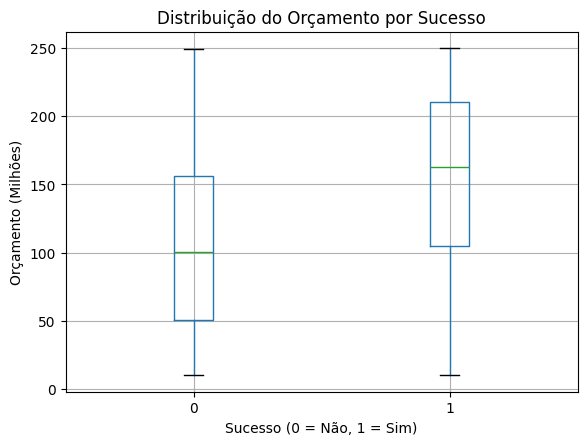

In [ ]:
import matplotlib.pyplot as plt

df.boxplot(column='Orcamento_M', by='Sucesso')
plt.title('Distribuição do Orçamento por Sucesso')
plt.suptitle('')
plt.xlabel('Sucesso (0 = Não, 1 = Sim)')
plt.ylabel('Orçamento (Milhões)')
plt.show()

### Visualização: Distribuição do Orçamento por Sucesso

O boxplot apresenta a distribuição do orçamento dos filmes separados entre sucesso (1) e fracasso (0).

Observa-se que filmes classificados como sucesso tendem a possuir, em média, orçamentos mais elevados, com uma mediana superior em comparação aos filmes que não tiveram sucesso.

No entanto, há sobreposição entre os grupos, indicando que, apesar de relevante, o orçamento não é o único fator determinante para o sucesso de um filme.

Esse comportamento reforça os resultados observados na análise de correlação, que indicaram uma relação positiva moderada entre orçamento e sucesso.

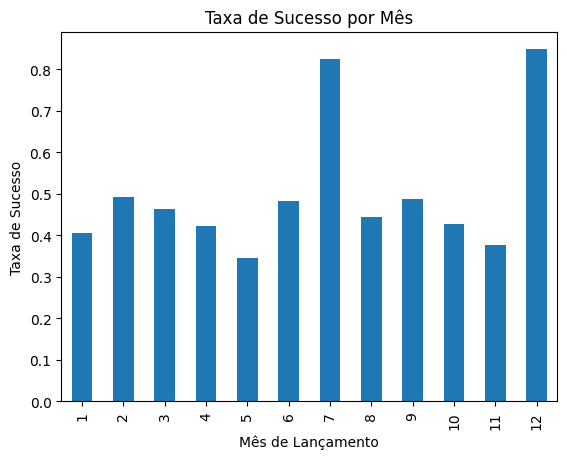

In [ ]:
# Média de sucesso por mês
sucesso_mes = df.groupby('Mes_Lancamento')['Sucesso'].mean()

# Gráfico de barras
sucesso_mes.plot(kind='bar')
plt.xlabel('Mês de Lançamento')
plt.ylabel('Taxa de Sucesso')
plt.title('Taxa de Sucesso por Mês')
plt.show()

### Visualização: Sucesso por Mês

O gráfico mostra a taxa de sucesso dos filmes ao longo dos meses.

É possível observar que os meses de Julho e Dezembro apresentam taxas significativamente maiores, confirmando a hipótese de que períodos de férias influenciam positivamente o desempenho dos filmes.

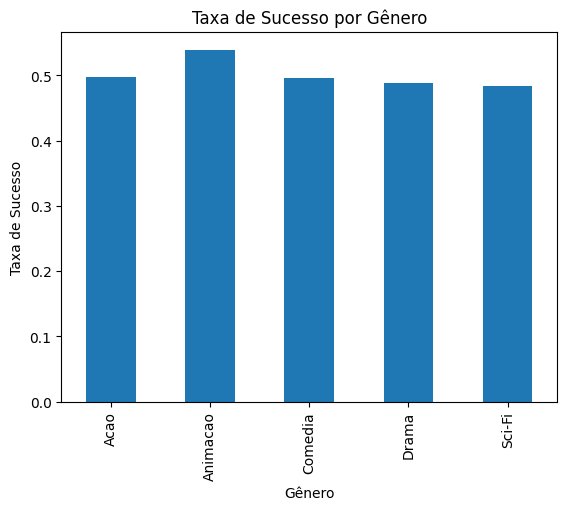

In [ ]:
# Média de sucesso por gênero
sucesso_genero = df.groupby('Genero')['Sucesso'].mean()

# Gráfico de barras
sucesso_genero.plot(kind='bar')
plt.xlabel('Gênero')
plt.ylabel('Taxa de Sucesso')
plt.title('Taxa de Sucesso por Gênero')
plt.show()

### Visualização: Sucesso por Gênero

O gráfico apresenta a taxa média de sucesso por gênero de filme.

Observa-se que as diferenças entre os gêneros são relativamente pequenas, indicando que o gênero, isoladamente, não é um fator determinante para o sucesso.

In [ ]:
# Separando as variáveis independentes (X) da variável alvo (y)

# X = variáveis de entrada (features)
X = df.drop('Sucesso', axis=1)

# y = variável alvo
y = df['Sucesso']

### Separação de Variáveis

Nesta etapa, os dados foram divididos entre variáveis de entrada (X) e variável alvo (y).

A variável "Sucesso" foi definida como alvo do modelo, enquanto as demais variáveis foram utilizadas como preditoras.

In [ ]:
# Aplicando One-Hot Encoding na variável 'Genero'

# Transformando variável categórica em numérica
X = pd.get_dummies(X, columns=['Genero'])

### Tratamento de Variáveis Categóricas

A variável "Genero", por ser categórica, foi transformada em formato numérico utilizando a técnica de One-Hot Encoding.

Esse processo cria novas colunas binárias (0 e 1), permitindo que o modelo de Machine Learning interprete corretamente os dados.

In [ ]:
# Normalizando a variável de orçamento para evitar distorções no modelo

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X[['Orcamento_M']] = scaler.fit_transform(X[['Orcamento_M']])

### Normalização dos Dados

A variável "Orcamento_M" foi normalizada utilizando MinMaxScaler, que transforma os valores para uma escala entre 0 e 1.

Essa etapa é importante para evitar que variáveis com valores muito altos tenham maior influência no modelo.

In [ ]:
# Dividindo os dados em treino (80%) e teste (20%)

from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Divisão dos Dados

Os dados foram divididos em conjuntos de treino e teste.

O conjunto de treino (80%) é utilizado para treinar o modelo, enquanto o conjunto de teste (20%) é utilizado para avaliar sua performance em dados não vistos.

Essa prática ajuda a evitar o overfitting e garante uma avaliação mais realista do modelo.

In [ ]:
# Criando e treinando o modelo de Árvore de Decisão
# Realizando previsões com os dados de teste

from sklearn.tree import DecisionTreeClassifier

# Criando o modelo
modelo_arvore = DecisionTreeClassifier(random_state=42)

# Treinando o modelo
modelo_arvore.fit(X_treino, y_treino)

# Fazendo previsões
y_pred_arvore = modelo_arvore.predict(X_teste)

### Modelo 1: Árvore de Decisão

Foi utilizado um modelo de Árvore de Decisão para classificar os filmes como sucesso ou fracasso.

Esse modelo é conhecido por sua interpretabilidade, permitindo visualizar as regras de decisão utilizadas.

In [ ]:
# Criando e treinando o modelo de Regressão Logística
# Realizando previsões com os dados de teste

from sklearn.linear_model import LogisticRegression

# Criando o modelo
modelo_log = LogisticRegression(max_iter=1000)

# Treinando
modelo_log.fit(X_treino, y_treino)

# Previsões
y_pred_log = modelo_log.predict(X_teste)

### Modelo 2: Regressão Logística

Também foi utilizado o modelo de Regressão Logística, que estima a probabilidade de um filme ser bem-sucedido com base nas variáveis de entrada.

Esse modelo é amplamente utilizado em problemas de classificação binária.

In [ ]:
# Gerando a matriz de confusão para o modelo de Árvore de Decisão

from sklearn.metrics import confusion_matrix

# Matriz de confusão - Árvore
cm_arvore = confusion_matrix(y_teste, y_pred_arvore)
cm_arvore

array([[101,  47],
       [ 46, 106]])

### Matriz de Confusão - Árvore de Decisão

A matriz de confusão mostra o desempenho do modelo ao comparar os valores reais com os previstos.

Ela permite identificar quantos filmes foram corretamente classificados como sucesso ou fracasso, bem como os erros cometidos pelo modelo.

101 - acertou fracassos (0)
106 - acertou sucessos (1)
47 - falso positivo (achou que seria sucesso, mas não foi)
46 - falso negativo (não detectou um sucesso)

In [ ]:
# Matriz de confusão - Regressão Logística
cm_log = confusion_matrix(y_teste, y_pred_log)
cm_log

array([[112,  36],
       [ 45, 107]])

### Matriz de Confusão - Regressão Logística

Assim como no modelo anterior, a matriz de confusão permite avaliar a capacidade da regressão logística em classificar corretamente os filmes.

112 - acertou fracassos (0)
107 - acertou sucessos (1)
36 - falso positivo (achou que seria sucesso, mas não foi)
45 - falso negativo (não detectou um sucesso)

In [ ]:
# Exibindo métricas como precisão, recall e F1-score

from sklearn.metrics import classification_report

# Relatório Árvore
print("Árvore de Decisão:\n")
print(classification_report(y_teste, y_pred_arvore))

# Relatório Regressão Logística
print("Regressão Logística:\n")
print(classification_report(y_teste, y_pred_log))

Árvore de Decisão:

              precision    recall  f1-score   support

           0       0.69      0.68      0.68       148
           1       0.69      0.70      0.70       152

    accuracy                           0.69       300
   macro avg       0.69      0.69      0.69       300
weighted avg       0.69      0.69      0.69       300

Regressão Logística:

              precision    recall  f1-score   support

           0       0.71      0.76      0.73       148
           1       0.75      0.70      0.73       152

    accuracy                           0.73       300
   macro avg       0.73      0.73      0.73       300
weighted avg       0.73      0.73      0.73       300



### Métricas de Avaliação

Foram utilizadas métricas como precisão (precision), recall e F1-score para avaliar o desempenho dos modelos.

O recall é especialmente importante, pois indica a capacidade do modelo de identificar corretamente os filmes que realmente serão sucesso.

### Análise dos Erros do Modelo

Um ponto crítico da análise é entender os erros do modelo, especialmente os falsos positivos.

Um falso positivo ocorre quando o modelo prevê que um filme será um sucesso, mas ele acaba fracassando.

Esse tipo de erro pode gerar grandes prejuízos financeiros, pois a empresa pode investir altos valores acreditando no sucesso do filme.

Portanto, é fundamental avaliar não apenas a acurácia, mas também o impacto dos erros no contexto de negócio.

### Comparação entre Modelos

Ao comparar os modelos, observa-se que a Regressão Logística apresentou melhor desempenho geral, com maior acurácia e menor número de falsos positivos em relação à Árvore de Decisão.

A redução de falsos positivos é especialmente importante no contexto de negócio, pois evita investimentos em filmes que poderiam fracassar.

A regressão logística reduz o risco de investimento em filmes que podem fracassar, sendo mais adequada para decisões financeiras.

Dessa forma, a Regressão Logística se mostra mais adequada para auxiliar na tomada de decisão estratégica.

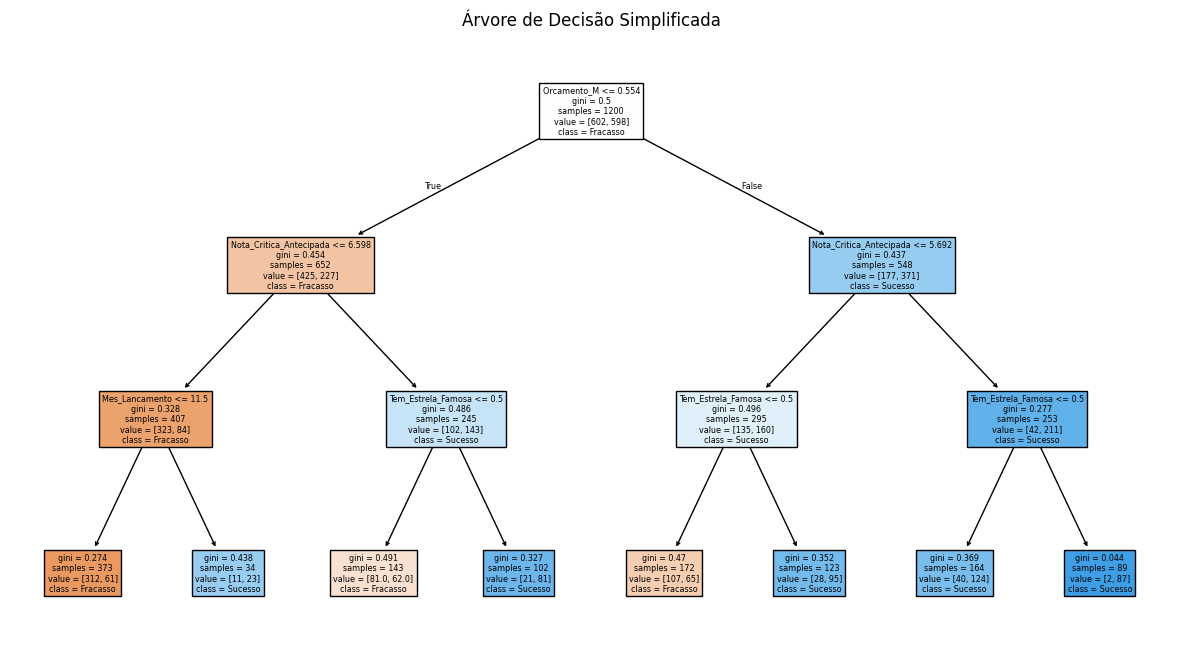

In [ ]:
# Visualizando a árvore de decisão para entender as regras do modelo

from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Criando modelo mais simples para evitar overfitting
modelo_arvore_simples = DecisionTreeClassifier(max_depth=3, random_state=42)

# Treinando
modelo_arvore_simples.fit(X_treino, y_treino)

# Plotando
plt.figure(figsize=(15,8))

plot_tree(
    modelo_arvore_simples,
    feature_names=X.columns,
    class_names=['Fracasso', 'Sucesso'],
    filled=True
)

plt.title("Árvore de Decisão Simplificada")
plt.show()

### Visualização da Árvore de Decisão (Simplificada)

Para facilitar a interpretação, foi criada uma versão simplificada da árvore de decisão, limitando sua profundidade.

Isso permite visualizar de forma mais clara as principais regras utilizadas pelo modelo.

A simplificação evita excesso de complexidade e torna o modelo mais interpretável, o que é essencial para análise de negócio.

### Interpretação da Árvore de Decisão

A análise da árvore permite identificar regras claras utilizadas pelo modelo.

A primeira divisão ocorre com base no orçamento, indicando que esse é um dos fatores mais importantes para a previsão.

Por exemplo:

- Se o orçamento for baixo (menor ou igual a aproximadamente 0.55 na escala normalizada) e a nota da crítica for baixa, o modelo tende a classificar o filme como fracasso.

- Se o orçamento for alto e a nota da crítica for elevada, o modelo tende a classificar o filme como sucesso.

- A presença de uma estrela famosa também influencia positivamente a previsão, aumentando a chance de sucesso.

O modelo indica que o sucesso de um filme depende em grande parte do orçamento, mas sendo influenciado também pela avaliação crítica, presença de estrelas e período de lançamento.

Essas regras confirmam os padrões observados na análise exploratória, reforçando que fatores como orçamento, avaliação crítica e presença de estrelas são determinantes para o sucesso de um filme.

### Conclusão do Projeto

O objetivo deste projeto foi desenvolver um modelo de Machine Learning capaz de prever o sucesso de filmes com base em características como orçamento, gênero, mês de lançamento, avaliação crítica e presença de estrelas famosas.

A análise exploratória revelou que fatores como orçamento e mês de lançamento (especialmente Julho e Dezembro) possuem forte influência no sucesso dos filmes, enquanto o gênero apresenta impacto mais moderado.

Na etapa de modelagem, foram utilizados dois algoritmos: Árvore de Decisão e Regressão Logística. A Regressão Logística apresentou melhor desempenho geral, com maior acurácia e menor número de falsos positivos.

A interpretação da árvore de decisão permitiu compreender as regras utilizadas pelo modelo, evidenciando que orçamento, nota da crítica e presença de estrelas são fatores determinantes.

Do ponto de vista de negócio, o modelo pode auxiliar a FilmeFlix na tomada de decisão sobre investimentos, reduzindo riscos e aumentando as chances de sucesso de novos filmes.

### Defesa do Modelo

Caso o modelo apresentasse um resultado inconsistente, como prever que todos os filmes seriam sucesso ou fracasso, isso poderia ser identificado através das métricas de avaliação.

A análise da matriz de confusão permitiria observar um desbalanceamento extremo nas previsões, enquanto métricas como precisão e recall indicariam desempenho inadequado.

Por exemplo, um recall muito alto combinado com baixa precisão pode indicar que o modelo está classificando muitos casos como sucesso de forma incorreta.

Esses sinais serviriam como alerta para revisar o modelo antes de sua utilização em um ambiente real.

### Insight de Negócio

Os resultados obtidos pelo modelo fazem sentido quando comparados com o mundo real.

Filmes lançados em períodos de férias, como Julho e Dezembro, tendem a ter maior público, o que justifica a maior taxa de sucesso nesses meses.

Além disso, filmes com maior orçamento geralmente possuem maior investimento em produção e marketing, aumentando suas chances de sucesso.

A influência da crítica e da presença de atores famosos também é coerente, pois esses fatores impactam diretamente a percepção do público e a decisão de assistir ao filme.

Portanto, os padrões identificados pelo modelo refletem comportamentos reais do mercado cinematográfico.